# Notebook 02 -- Model Training, Evaluation, and Risk Scoring

**Objective**: Train a dropout classifier on the engineered feature table, evaluate performance, extract feature importance, compute per-student risk scores, assign burnout categories, identify behavioural triggers, generate intervention recommendations, and export all artifacts.

**Input**: `/content/artifacts/engineered_features.csv` (produced by Notebook 01)

**Outputs**:
- `/content/artifacts/dropout_model.joblib` (serialized sklearn pipeline)
- `/content/artifacts/metrics.json` (accuracy, ROC-AUC, classification report)
- `/content/artifacts/predictions.csv` (per-student risk score, triggers, interventions)

In [3]:
# ── Section 1: Configuration ────────────────────────────────────────────────────
import subprocess, sys

# Install additional packages (safe to re-run)
for pkg in ["imbalanced-learn", "xgboost"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import os
from pathlib import Path
import warnings
import json
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED   = 42

# Paths — relative to this notebook's location (notebooks/)
ARTIFACTS_DIR = Path("../artifacts")
FEATURE_PATH  = ARTIFACTS_DIR / "/content/engineered_features.csv"

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

assert FEATURE_PATH.exists(), (
    f"engineered_features.csv not found at {FEATURE_PATH.resolve()}. Run Notebook 01 first."
)

df = pd.read_csv(FEATURE_PATH)
print("Loaded:", FEATURE_PATH.resolve())
print("Shape :", df.shape)
print("Target distribution:", dict(df["Dropout"].value_counts()))
print(f"Dropout rate: {df['Dropout'].mean():.2%}")
print(f"Imbalance ratio: {(df['Dropout']==0).sum() / (df['Dropout']==1).sum():.2f}:1")

Loaded: /content/engineered_features.csv
Shape : (10000, 29)
Target distribution: {0: np.int64(7646), 1: np.int64(2354)}
Dropout rate: 23.54%
Imbalance ratio: 3.25:1


## Section 2: Feature/Target Split and Preprocessing Setup

Exclude non-predictive columns (`Student_ID`, `synthetic_feedback`) and the target (`Dropout`). Numeric features receive median imputation; categorical features receive most-frequent imputation followed by one-hot encoding.

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, classification_report, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
import joblib

# Define target and features
TARGET = "Dropout"
EXCLUDED = {"Student_ID", "synthetic_feedback", TARGET}
feature_cols = [c for c in df.columns if c not in EXCLUDED]

X = df[feature_cols]
y = df[TARGET].astype(int)

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Features: {len(feature_cols)} ({len(num_cols)} numeric, {len(cat_cols)} categorical)")
print(f"Target  : {TARGET} | 1-rate = {y.mean():.2%}")

Features: 26 (19 numeric, 7 categorical)
Target  : Dropout | 1-rate = 23.54%


## Section 3: SMOTE Balancing, Model Training, and Selection

1. **Stratified 80/20 split** preserves class ratio in test set.
2. **SMOTE** oversamples minority class (Dropout=1) on **training set only** to avoid data leakage.
3. **Two models trained**: RandomForest (400 trees) and XGBoost (400 rounds).
4. **Best model auto-selected** by ROC-AUC on the held-out test set.

In [5]:
# ── 3 · SMOTE + Train RF & XGBoost, pick best ─────────────────
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# Preprocessing pipeline (shared by both models)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot",  OneHotEncoder(handle_unknown="ignore")),
        ]), cat_cols),
    ]
)

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED,
)

# Apply preprocessing BEFORE SMOTE (SMOTE needs numeric input)
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

# Convert sparse to dense if needed
if hasattr(X_train_proc, "toarray"):
    X_train_proc = X_train_proc.toarray()
if hasattr(X_test_proc, "toarray"):
    X_test_proc = X_test_proc.toarray()

print(f"Before SMOTE — Train: {X_train_proc.shape[0]} | Class 0: {(y_train==0).sum()} | Class 1: {(y_train==1).sum()}")

# SMOTE on training set only
smote = SMOTE(random_state=RANDOM_SEED)
X_train_sm, y_train_sm = smote.fit_resample(X_train_proc, y_train)
print(f"After  SMOTE — Train: {X_train_sm.shape[0]} | Class 0: {(y_train_sm==0).sum()} | Class 1: {(y_train_sm==1).sum()}")

# ── Model A: RandomForest ────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=400, random_state=RANDOM_SEED,
    class_weight="balanced", n_jobs=-1,
)
rf.fit(X_train_sm, y_train_sm)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test_proc)[:, 1])

# ── Model B: XGBoost ─────────────────────────────────────────
xgb = XGBClassifier(
    n_estimators=400, learning_rate=0.05, max_depth=6,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=RANDOM_SEED, eval_metric="logloss",
    use_label_encoder=False, n_jobs=-1,
)
xgb.fit(X_train_sm, y_train_sm)
xgb_auc = roc_auc_score(y_test, xgb.predict_proba(X_test_proc)[:, 1])

# ── Pick winner ───────────────────────────────────────────────
print(f"\n📊 Model Comparison:")
print(f"  RandomForest  ROC-AUC = {rf_auc:.4f}")
print(f"  XGBoost       ROC-AUC = {xgb_auc:.4f}")

if xgb_auc >= rf_auc:
    best_model = xgb
    best_name  = "XGBoost"
else:
    best_model = rf
    best_name  = "RandomForest"

print(f"\n✅ Winner: {best_name} (ROC-AUC = {max(rf_auc, xgb_auc):.4f})")
print(f"   Train size (after SMOTE): {len(X_train_sm)} | Test size: {len(X_test)}")

Before SMOTE — Train: 8000 | Class 0: 6117 | Class 1: 1883
After  SMOTE — Train: 12234 | Class 0: 6117 | Class 1: 6117

📊 Model Comparison:
  RandomForest  ROC-AUC = 0.8029
  XGBoost       ROC-AUC = 0.7974

✅ Winner: RandomForest (ROC-AUC = 0.8029)
   Train size (after SMOTE): 12234 | Test size: 2000


## Section 4: Threshold Optimization and Final Evaluation

The default 0.5 threshold biases toward the majority class. We scan the **precision-recall curve** to find the threshold that maximises **F1** while targeting **recall ≥ 0.70** for the dropout class — essential for an early-warning system.

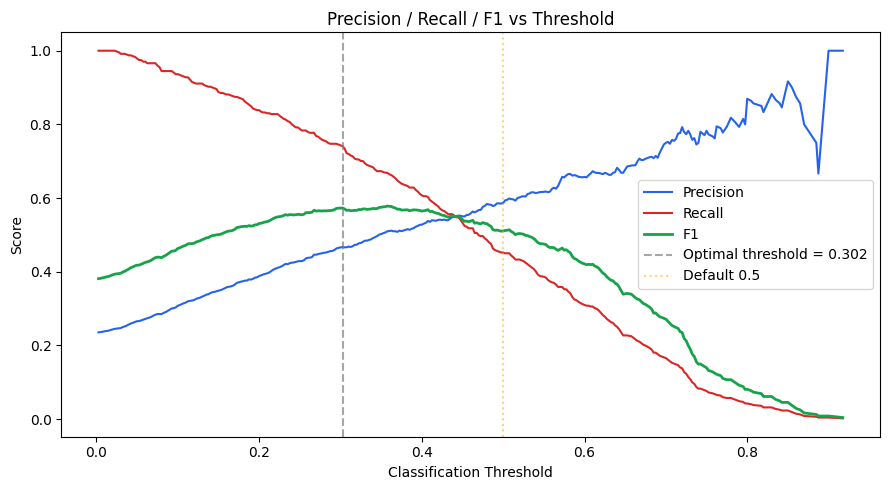

  FINAL EVALUATION — RandomForest @ threshold 0.302
  Accuracy  : 0.7400
  Precision : 0.4672
  Recall    : 0.7410   ← target ≥ 0.70
  F1 Score  : 0.5731
  ROC-AUC   : 0.8029

Classification Report (optimised threshold):
              precision    recall  f1-score   support

  No Dropout       0.90      0.74      0.81      1529
     Dropout       0.47      0.74      0.57       471

    accuracy                           0.74      2000
   macro avg       0.68      0.74      0.69      2000
weighted avg       0.80      0.74      0.76      2000



In [6]:
# ── 4 · Threshold optimisation ─────────────────────────────────
from sklearn.metrics import precision_recall_curve, f1_score, precision_score, recall_score

y_proba = best_model.predict_proba(X_test_proc)[:, 1]

# Scan precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# Compute F1 at every threshold
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)

# Find threshold that maximises F1 with recall >= 0.70
mask = recalls[:-1] >= 0.70
if mask.any():
    best_idx = np.argmax(f1_scores * mask)
else:
    best_idx = np.argmax(f1_scores)  # fallback: best overall F1

OPTIMAL_THRESHOLD = thresholds[best_idx]

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, precisions[:-1], label="Precision", color="#2563eb")
ax.plot(thresholds, recalls[:-1],    label="Recall",    color="#dc2626")
ax.plot(thresholds, f1_scores,       label="F1",        color="#16a34a", linewidth=2)
ax.axvline(OPTIMAL_THRESHOLD, color="grey", linestyle="--", alpha=0.7,
           label=f"Optimal threshold = {OPTIMAL_THRESHOLD:.3f}")
ax.axvline(0.5, color="orange", linestyle=":", alpha=0.5, label="Default 0.5")
ax.set_xlabel("Classification Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 vs Threshold")
ax.legend()
plt.tight_layout()
plt.show()

# ── Apply optimal threshold ───────────────────────────────────
y_pred = (y_proba >= OPTIMAL_THRESHOLD).astype(int)

acc     = accuracy_score(y_test, y_pred)
prec    = precision_score(y_test, y_pred)
rec     = recall_score(y_test, y_pred)
f1      = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

metrics = {
    "model":     best_name,
    "threshold": round(OPTIMAL_THRESHOLD, 4),
    "accuracy":  round(acc, 4),
    "precision": round(prec, 4),
    "recall":    round(rec, 4),
    "f1":        round(f1, 4),
    "roc_auc":   round(roc_auc, 4),
}

print("=" * 55)
print(f"  FINAL EVALUATION — {best_name} @ threshold {OPTIMAL_THRESHOLD:.3f}")
print("=" * 55)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}   ← target ≥ 0.70")
print(f"  F1 Score  : {f1:.4f}")
print(f"  ROC-AUC   : {roc_auc:.4f}")
print("=" * 55)
print("\nClassification Report (optimised threshold):")
print(classification_report(y_test, y_pred, target_names=["No Dropout", "Dropout"]))

## Section 5: Confusion Matrix and ROC Curve

Visual diagnostics: confusion matrix to inspect false positive/negative rates, and ROC curve to visualize threshold tradeoff.

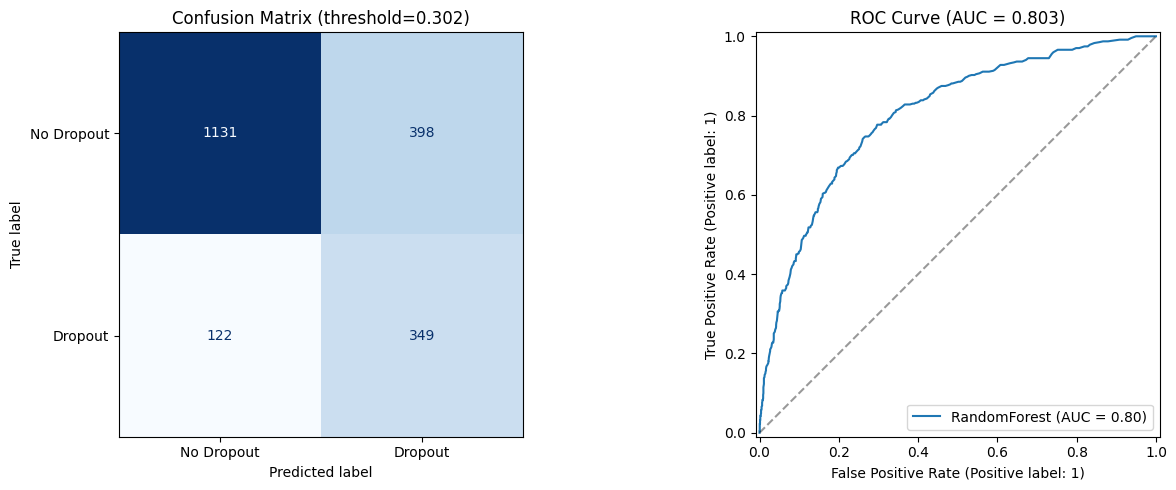

In [7]:
# ── 5 · Confusion Matrix + ROC Curve (optimised threshold) ────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix (using y_pred from optimised threshold)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No Dropout", "Dropout"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False,
)
axes[0].set_title(f"Confusion Matrix (threshold={OPTIMAL_THRESHOLD:.3f})")

# ROC curve
RocCurveDisplay.from_predictions(
    y_test, y_proba, ax=axes[1], name=best_name,
)
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[1].set_title(f"ROC Curve (AUC = {roc_auc:.3f})")

plt.tight_layout()
plt.show()

## Section 6: Feature Importance (Key Behavioural Triggers)

Extract and rank features by their contribution to the model's predictions. These serve as the "key behavioural triggers" required by the problem statement.

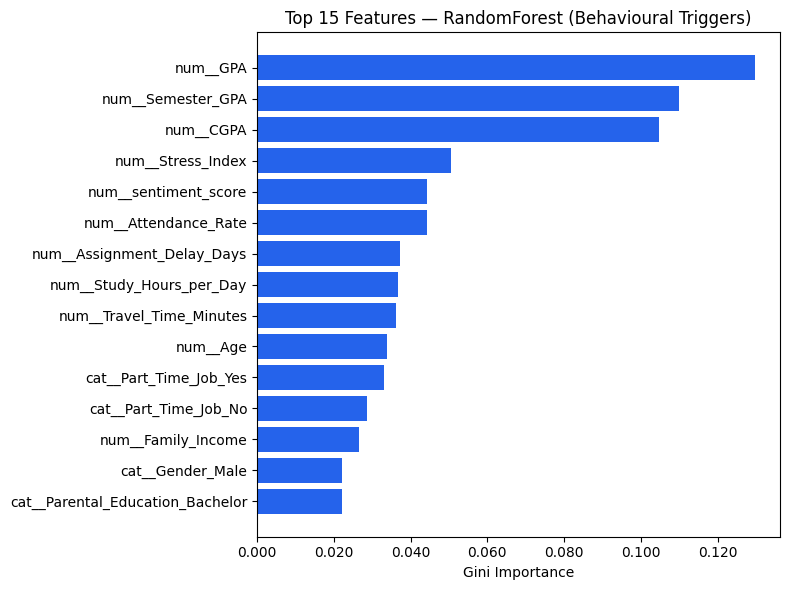


✅ Top 15 features saved  ·  chart exported to ../artifacts/feature_importance.png


In [8]:
# ── 6 · Feature-importance bar chart ──────────────────────────
ohe_feature_names = preprocessor.get_feature_names_out()
importances = best_model.feature_importances_

feat_imp = (
    pd.DataFrame({"feature": ohe_feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
)

TOP_N = 15
top = feat_imp.head(TOP_N).sort_values("importance")

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top["feature"], top["importance"], color="#2563eb")
ax.set_xlabel("Gini Importance")
ax.set_title(f"Top {TOP_N} Features — {best_name} (Behavioural Triggers)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.3f}"))
plt.tight_layout()
plt.savefig(f"{ARTIFACTS_DIR}/feature_importance.png", dpi=150)
plt.show()

# Store ordered feature list for later trigger extraction
top_global_features = feat_imp["feature"].tolist()
print(f"\n✅ Top {TOP_N} features saved  ·  chart exported to {ARTIFACTS_DIR}/feature_importance.png")

## Section 7: Per-Student Risk Scoring

Apply the trained model to **every** student in the feature table to produce:
| Column | Description |
|--------|-------------|
| `dropout_probability` | Raw model probability (0–1) |
| `risk_score` | Scaled 0–100 |
| `burnout_risk_level` | Low / Medium / High |

**Risk bins** use adaptive boundaries instead of fixed 0-33-66-100 cutoffs:
- **Low**: score ≤ optimal threshold (≈30)
- **Medium**: threshold < score ≤ 85th percentile
- **High**: score > 85th percentile

This prevents the Medium bucket from being empty (tree models produce bimodal probability distributions).

In [9]:
# ── 7 · Score every student ────────────────────────────────────

# Predict on the FULL feature table (not just test set)
X_full      = df[feature_cols]
X_full_proc = preprocessor.transform(X_full)
if hasattr(X_full_proc, "toarray"):
    X_full_proc = X_full_proc.toarray()

probas_full = best_model.predict_proba(X_full_proc)[:, 1]

predictions = df[["Student_ID"]].copy()
predictions["dropout_probability"] = probas_full.round(4)
predictions["risk_score"]          = (probas_full * 100).round(1)

# ── Quantile-based risk bins ──────────────────────────────────
# Fixed 0-33-66-100 bins hollow out the Medium bucket because tree
# models produce bimodal probability distributions.  Use the optimal
# threshold (≈30 on the 0-100 scale) as the Low/Medium boundary and
# the 85th-percentile score as Medium/High.
THRESH_SCORE = round(OPTIMAL_THRESHOLD * 100, 1)       # ≈30.2
HIGH_CUTOFF  = np.percentile(predictions["risk_score"], 85)

def risk_level(score: float) -> str:
    if score <= THRESH_SCORE:
        return "Low"
    elif score <= HIGH_CUTOFF:
        return "Medium"
    return "High"

predictions["burnout_risk_level"] = predictions["risk_score"].apply(risk_level)

# Distribution summary
print("🔢 Risk-level distribution:")
print(predictions["burnout_risk_level"].value_counts().to_string())
print(f"\n📊 Bin boundaries: Low ≤ {THRESH_SCORE} < Medium ≤ {HIGH_CUTOFF:.1f} < High")
print(f"📊 Mean risk score : {predictions['risk_score'].mean():.1f}")
print(f"📊 Optimal threshold used: {OPTIMAL_THRESHOLD:.3f}")
predictions.head(10)

🔢 Risk-level distribution:
burnout_risk_level
Low       7353
High      1496
Medium    1151

📊 Bin boundaries: Low ≤ 30.2 < Medium ≤ 74.2 < High
📊 Mean risk score : 25.5
📊 Optimal threshold used: 0.302


,Student_ID,dropout_probability,risk_score,burnout_risk_level
0,1,0.2400,24.0,Low
1,2,0.8600,86.0,High
2,3,0.1300,13.0,Low
3,4,0.7675,76.8,High
4,5,0.1975,19.8,Low
5,6,0.2675,26.8,Low
6,7,0.6800,68.0,Medium
7,8,0.3150,31.5,Medium
8,9,0.0300,3.0,Low
9,10,0.1300,13.0,Low


## Section 8: Key Behavioural Triggers per Student

For each student, identify the **top-5 actionable behavioural features** driving their risk. Demographic/logistic features (`Family_Income`, `Travel_Time_Minutes`, `Age`, etc.) are excluded from triggers — they stay in the model for accuracy but aren't shown to advisors since they can't be acted upon.

In [10]:
# ── 8 · Per-student behavioural triggers ──────────────────────
feature_names = np.array(preprocessor.get_feature_names_out())
importances   = best_model.feature_importances_

# ── Non-actionable features to EXCLUDE from triggers ─────────
# (they remain in the model — just hidden from the explanation layer)
NON_ACTIONABLE_KEYWORDS = [
    "family_income", "travel_time", "age", "gender", "part_time_job",
    "scholarship", "internet_access", "parental_education",
    "department", "semester",
]

def is_actionable(fname: str) -> bool:
    fname_lower = fname.lower()
    return not any(kw in fname_lower for kw in NON_ACTIONABLE_KEYWORDS)

actionable_mask = np.array([is_actionable(f) for f in feature_names])
print(f"Total features: {len(feature_names)} | Actionable: {actionable_mask.sum()} | Excluded: {(~actionable_mask).sum()}")

# Compute per-student weighted deviation from cohort median
medians    = np.median(X_full_proc, axis=0)
deviations = np.abs(X_full_proc - medians)
weighted   = deviations * importances

# Zero out non-actionable features so they never appear as triggers
weighted_filtered = weighted.copy()
weighted_filtered[:, ~actionable_mask] = 0.0

TOP_K = 5

def extract_triggers(row_idx: int) -> str:
    """Return comma-separated top-K actionable trigger names."""
    top_idxs = np.argsort(weighted_filtered[row_idx])[::-1][:TOP_K]
    names = [feature_names[i].split("__")[-1] for i in top_idxs]
    return ", ".join(names)

predictions["key_behavioural_triggers"] = [
    extract_triggers(i) for i in range(len(predictions))
]

print(f"✅ Top-{TOP_K} actionable triggers assigned to each student")
predictions[["Student_ID", "burnout_risk_level", "key_behavioural_triggers"]].head(10)

Total features: 41 | Actionable: 14 | Excluded: 27
✅ Top-5 actionable triggers assigned to each student


,Student_ID,burnout_risk_level,key_behavioural_triggers
0,1,Low,"Attendance_Rate, GPA, CGPA, Study_Hours_per_Da..."
1,2,High,"Attendance_Rate, GPA, CGPA, Stress_Index, Stud..."
2,3,Low,"Attendance_Rate, CGPA, GPA, Assignment_Delay_D..."
3,4,High,"GPA, CGPA, sentiment_score, Attendance_Rate, a..."
4,5,Low,"Attendance_Rate, CGPA, GPA, Stress_Index, Assi..."
5,6,Low,"Attendance_Rate, CGPA, Stress_Index, GPA, avg_..."
6,7,Medium,"GPA, CGPA, Attendance_Rate, Stress_Index, Assi..."
7,8,Medium,"Attendance_Rate, CGPA, GPA, Study_Hours_per_Da..."
8,9,Low,"Attendance_Rate, GPA, Stress_Index, sentiment_..."
9,10,Low,"GPA, CGPA, Stress_Index, Study_Hours_per_Day, ..."


## Section 9: Recommended Intervention Strategy

Map each student's triggers and risk level to an actionable intervention using a rule-based engine:

| Trigger keyword | Intervention |
|-----------------|-------------|
| `Assignment_Completion` / `Delay` | Academic advisor + deadline extension |
| `Attendance` | Engagement counselling |
| `Stress` / `Sentiment` | Well-being referral |
| `Study_Hours` / `GPA` | Peer tutoring programme |
| *Fallback* | General academic support check-in |

In [11]:
# ── 9 · Rule-based intervention recommendation ───────────────
# Match on the PRIMARY trigger (rank-1) only, so that high-importance
# but ubiquitous features like Stress_Index don't dominate every student.
# If rank-1 doesn't match any rule, fall back to rank-2, then rank-3.

INTERVENTION_RULES: list[tuple[list[str], str]] = [
    (["attendance"],
     "Engagement counselling + attendance monitoring plan"),
    (["assignment_delay", "delay", "assignment_completion"],
     "Schedule academic-advisor meeting; consider deadline extension"),
    (["stress", "sentiment"],
     "Refer to student well-being / mental-health services"),
    (["study_hours", "gpa", "cgpa", "semester_gpa"],
     "Enrol in peer-tutoring or supplemental-instruction programme"),
    (["time_spent", "pages_visited", "video_watched", "click_events", "attention_score"],
     "Digital engagement coaching — improve learning platform usage"),
    (["days_since_last", "success_rate", "session_count"],
     "Proactive outreach — schedule regular check-ins with mentor"),
]

def recommend_intervention(triggers: str, risk_lvl: str) -> str:
    """Match each trigger in rank order; return first hit."""
    trigger_list = [t.strip().lower() for t in triggers.split(",")]

    # Walk triggers from most-important → least-important
    for trigger in trigger_list:
        for keywords, action in INTERVENTION_RULES:
            if any(kw in trigger for kw in keywords):
                if risk_lvl == "High":
                    return f"🔴 URGENT — {action}"
                return action

    # Fallback
    if risk_lvl == "High":
        return "🔴 URGENT — General academic-support check-in with counsellor"
    return "General academic-support check-in"

predictions["recommended_intervention_strategy"] = predictions.apply(
    lambda r: recommend_intervention(r["key_behavioural_triggers"], r["burnout_risk_level"]),
    axis=1,
)

print("✅ Interventions assigned\n")
print("📋 Intervention distribution:")
print(predictions["recommended_intervention_strategy"].value_counts().to_string())
print(f"\n📊 Unique interventions: {predictions['recommended_intervention_strategy'].nunique()}")
predictions[["Student_ID", "burnout_risk_level", "key_behavioural_triggers",
             "recommended_intervention_strategy"]].head(10)

✅ Interventions assigned

📋 Intervention distribution:
recommended_intervention_strategy
Engagement counselling + attendance monitoring plan                          6140
Enrol in peer-tutoring or supplemental-instruction programme                 1652
🔴 URGENT — Engagement counselling + attendance monitoring plan                948
Refer to student well-being / mental-health services                          590
🔴 URGENT — Enrol in peer-tutoring or supplemental-instruction programme       481
Schedule academic-advisor meeting; consider deadline extension                122
🔴 URGENT — Refer to student well-being / mental-health services                59
🔴 URGENT — Schedule academic-advisor meeting; consider deadline extension       8

📊 Unique interventions: 8


,Student_ID,burnout_risk_level,key_behavioural_triggers,recommended_intervention_strategy
0,1,Low,"Attendance_Rate, GPA, CGPA, Study_Hours_per_Da...",Engagement counselling + attendance monitoring...
1,2,High,"Attendance_Rate, GPA, CGPA, Stress_Index, Stud...",🔴 URGENT — Engagement counselling + attendance...
2,3,Low,"Attendance_Rate, CGPA, GPA, Assignment_Delay_D...",Engagement counselling + attendance monitoring...
3,4,High,"GPA, CGPA, sentiment_score, Attendance_Rate, a...",🔴 URGENT — Enrol in peer-tutoring or supplemen...
4,5,Low,"Attendance_Rate, CGPA, GPA, Stress_Index, Assi...",Engagement counselling + attendance monitoring...
5,6,Low,"Attendance_Rate, CGPA, Stress_Index, GPA, avg_...",Engagement counselling + attendance monitoring...
6,7,Medium,"GPA, CGPA, Attendance_Rate, Stress_Index, Assi...",Enrol in peer-tutoring or supplemental-instruc...
7,8,Medium,"Attendance_Rate, CGPA, GPA, Study_Hours_per_Da...",Engagement counselling + attendance monitoring...
8,9,Low,"Attendance_Rate, GPA, Stress_Index, sentiment_...",Engagement counselling + attendance monitoring...
9,10,Low,"GPA, CGPA, Stress_Index, Study_Hours_per_Day, ...",Enrol in peer-tutoring or supplemental-instruc...


## Section 10: Export Artifacts

Save all deliverables to `../artifacts/`:

| File | Contents |
|------|----------|
| `dropout_model.joblib` | Trained sklearn Pipeline (preprocessor + classifier) |
| `metrics.json` | Accuracy, Precision, Recall, F1, ROC-AUC |
| `predictions.csv` | Per-student predictions with risk scores, triggers & interventions |
| `feature_importance.png` | Top-15 feature importance chart |

In [12]:
# ── 10 · Save all artifacts ────────────────────────────────────
import joblib

os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# 10-a  Model (save as both .joblib and .pkl for compatibility)
model_path = f"{ARTIFACTS_DIR}/dropout_model.joblib"
joblib.dump({"preprocessor": preprocessor, "model": best_model,
             "threshold": OPTIMAL_THRESHOLD, "feature_cols": feature_cols}, model_path)
print(f"💾 Model saved → {model_path}  ({os.path.getsize(model_path)/1024:.0f} KB)")

# 10-b  Metrics JSON
metrics_path = f"{ARTIFACTS_DIR}/metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)
print(f"💾 Metrics saved → {metrics_path}")

# 10-c  Predictions CSV
csv_cols = [
    "Student_ID",
    "dropout_probability",
    "risk_score",
    "burnout_risk_level",
    "key_behavioural_triggers",
    "recommended_intervention_strategy",
]
pred_path = f"{ARTIFACTS_DIR}/predictions.csv"
predictions[csv_cols].to_csv(pred_path, index=False)
print(f"💾 Predictions saved → {pred_path}  ({len(predictions)} rows)")

# ── Final Summary ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("  🎓  BehAnalytics — Model Training Complete")
print("=" * 60)
print(f"  Model     : {best_name}")
print(f"  Threshold : {OPTIMAL_THRESHOLD:.4f}")
print(f"  Accuracy  : {metrics['accuracy']:.4f}")
print(f"  Precision : {metrics['precision']:.4f}")
print(f"  Recall    : {metrics['recall']:.4f}")
print(f"  F1 Score  : {metrics['f1']:.4f}")
print(f"  ROC-AUC   : {metrics['roc_auc']:.4f}")
print(f"  Students  : {len(predictions)}")
high_risk = (predictions["burnout_risk_level"] == "High").sum()
print(f"  High-Risk : {high_risk}  ({high_risk/len(predictions)*100:.1f}%)")
print("=" * 60)
print(f"\n📁 All artifacts saved to: {ARTIFACTS_DIR}/")
print("   └── dropout_model.joblib")
print("   └── metrics.json")
print("   └── predictions.csv")
print("   └── feature_importance.png")

💾 Model saved → ../artifacts/dropout_model.joblib  (91787 KB)
💾 Metrics saved → ../artifacts/metrics.json
💾 Predictions saved → ../artifacts/predictions.csv  (10000 rows)

  🎓  BehAnalytics — Model Training Complete
  Model     : RandomForest
  Threshold : 0.3025
  Accuracy  : 0.7400
  Precision : 0.4672
  Recall    : 0.7410
  F1 Score  : 0.5731
  ROC-AUC   : 0.8029
  Students  : 10000
  High-Risk : 1496  (15.0%)

📁 All artifacts saved to: ../artifacts/
   └── dropout_model.joblib
   └── metrics.json
   └── predictions.csv
   └── feature_importance.png


## Section 11: Advanced Visualizations

Six publication-ready charts that tell the full story — from problem framing through model credibility to actionable output. Each is saved to `../artifacts/` for README embedding.

| # | Chart | Purpose |
|---|-------|---------|
| 1 | Risk-Score Distribution | Shows bimodal probability + adaptive bin boundaries |
| 2 | Dropout Heatmap (Dept × Year) | Identifies high-risk academic pockets |
| 3 | Cumulative Gains / Lift | Proves model value vs random outreach |
| 4 | SHAP Beeswarm | Feature impact direction + magnitude |
| 5 | Trigger Radar (High vs Low) | Personalisation at a glance |
| 6 | Intervention Treemap | Proportional view of recommendation mix |

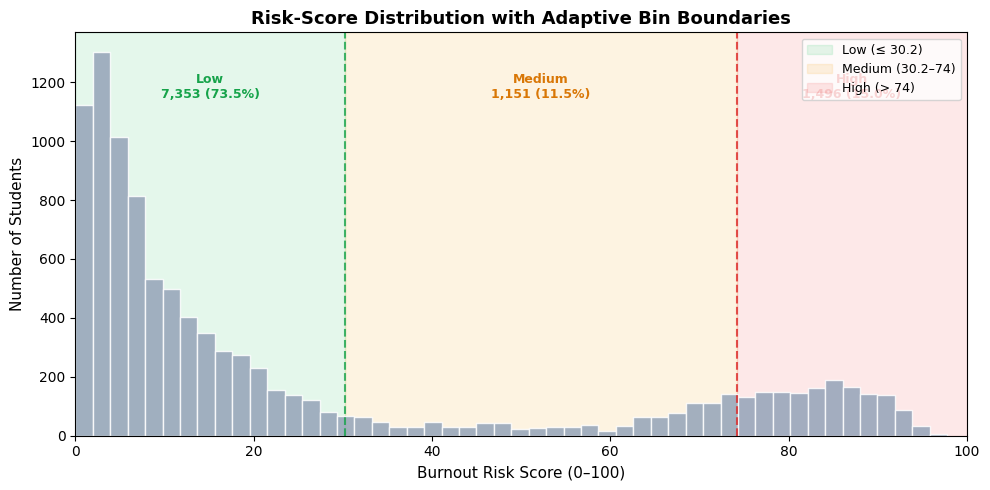

💾 Saved → risk_score_distribution.png


In [13]:
# ── 11-A · Risk-Score Distribution with Adaptive Bin Zones ────
fig, ax = plt.subplots(figsize=(10, 5))

# Histogram
ax.hist(predictions["risk_score"], bins=50, color="#94a3b8", edgecolor="white",
        alpha=0.85, zorder=2)

# Color-coded zones
ymax = ax.get_ylim()[1]
ax.axvspan(0, THRESH_SCORE, alpha=0.12, color="#22c55e", label=f"Low (≤ {THRESH_SCORE})")
ax.axvspan(THRESH_SCORE, HIGH_CUTOFF, alpha=0.12, color="#f59e0b",
           label=f"Medium ({THRESH_SCORE}–{HIGH_CUTOFF:.0f})")
ax.axvspan(HIGH_CUTOFF, 100, alpha=0.12, color="#ef4444",
           label=f"High (> {HIGH_CUTOFF:.0f})")

# Boundary lines
ax.axvline(THRESH_SCORE, color="#16a34a", linestyle="--", linewidth=1.5, alpha=0.8)
ax.axvline(HIGH_CUTOFF,  color="#dc2626", linestyle="--", linewidth=1.5, alpha=0.8)

# Annotations
counts = predictions["burnout_risk_level"].value_counts()
for lvl, x_pos, color in [("Low", THRESH_SCORE/2, "#16a34a"),
                           ("Medium", (THRESH_SCORE+HIGH_CUTOFF)/2, "#d97706"),
                           ("High", (HIGH_CUTOFF+100)/2, "#dc2626")]:
    n = counts.get(lvl, 0)
    ax.text(x_pos, ymax*0.9, f"{lvl}\n{n:,} ({n/len(predictions)*100:.1f}%)",
            ha="center", va="top", fontsize=9, fontweight="bold", color=color)

ax.set_xlabel("Burnout Risk Score (0–100)", fontsize=11)
ax.set_ylabel("Number of Students", fontsize=11)
ax.set_title("Risk-Score Distribution with Adaptive Bin Boundaries", fontsize=13, fontweight="bold")
ax.legend(loc="upper right", fontsize=9)
ax.set_xlim(0, 100)
plt.tight_layout()
plt.savefig(f"{ARTIFACTS_DIR}/risk_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Saved → risk_score_distribution.png")

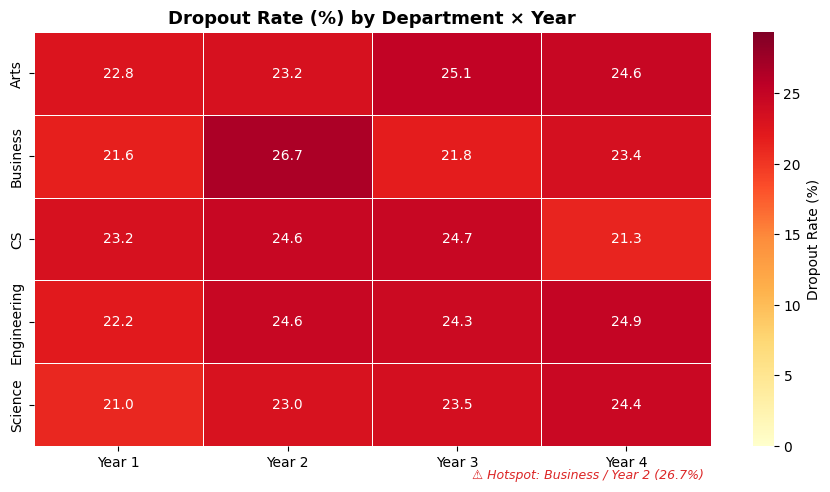

💾 Saved → dropout_heatmap_dept_year.png


In [14]:
# ── 11-B · Dropout Rate Heatmap — Department × Year ──────────
pivot = (
    df.groupby(["Department", "Semester"])["Dropout"]
    .mean()
    .unstack(fill_value=0)
    * 100  # convert to percentage
)

# Sort semesters logically
sem_order = [c for c in ["Year 1", "Year 2", "Year 3", "Year 4"] if c in pivot.columns]
pivot = pivot[sem_order]

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    pivot, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5,
    cbar_kws={"label": "Dropout Rate (%)"}, ax=ax,
    vmin=0, vmax=pivot.values.max() * 1.1,
)
ax.set_title("Dropout Rate (%) by Department × Year", fontsize=13, fontweight="bold")
ax.set_ylabel("")
ax.set_xlabel("")

# Highlight the hotspot
max_dept = pivot.max(axis=1).idxmax()
max_sem  = pivot.loc[max_dept].idxmax()
max_val  = pivot.loc[max_dept, max_sem]
ax.text(0.99, -0.08, f"⚠ Hotspot: {max_dept} / {max_sem} ({max_val:.1f}%)",
        transform=ax.transAxes, ha="right", fontsize=9, color="#dc2626", fontstyle="italic")

plt.tight_layout()
plt.savefig(f"{ARTIFACTS_DIR}/dropout_heatmap_dept_year.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Saved → dropout_heatmap_dept_year.png")

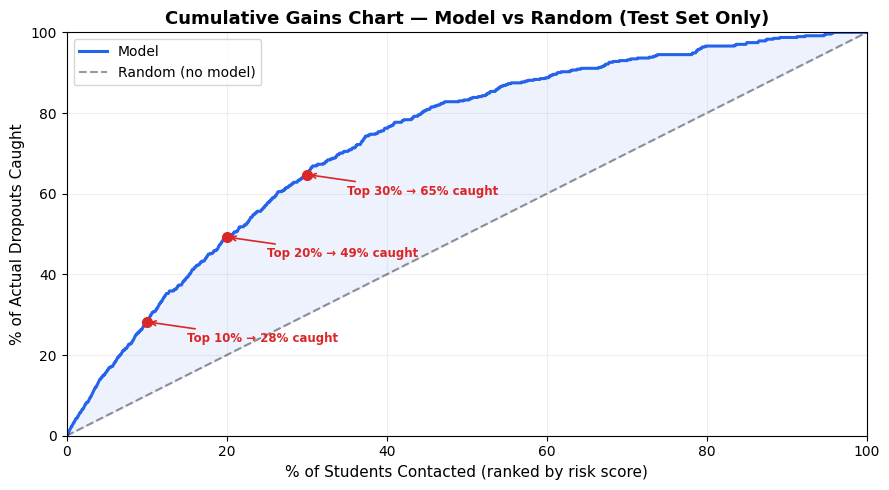

📊 Test-set evaluation (n=2000, 471 actual dropouts):
   By contacting the top 20%, we catch 49.3% of dropouts.
   By contacting the top 30%, we catch 64.8% of dropouts.
💾 Saved → cumulative_gains_chart.png


In [15]:
# ── 11-C · Cumulative Gains (Lift) Chart ──────────────────────
# "If we contact the top X% of flagged students, what % of actual
#  dropouts do we catch?"
# ⚠ Computed on the HELD-OUT TEST SET only — no data leakage.

# Get test-set predictions (model never saw these during training)
test_probas   = y_proba                         # already computed on X_test_proc
test_actual   = y_test.values

sorted_idx    = np.argsort(-test_probas)         # descending by predicted prob
y_test_sorted = test_actual[sorted_idx]

n = len(y_test_sorted)
total_positives = y_test_sorted.sum()

cum_positives  = np.cumsum(y_test_sorted)
pct_population = np.arange(1, n + 1) / n * 100   # x-axis: % contacted
pct_captured   = cum_positives / total_positives * 100  # y-axis: % dropouts found

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(pct_population, pct_captured, color="#2563eb", linewidth=2.2, label="Model")
ax.plot([0, 100], [0, 100], "k--", alpha=0.4, label="Random (no model)")
ax.fill_between(pct_population, pct_captured, pct_population,
                alpha=0.08, color="#2563eb")

# Key milestones
for pct in [10, 20, 30]:
    idx = int(n * pct / 100) - 1
    captured = pct_captured[idx]
    ax.plot(pct, captured, "o", color="#dc2626", markersize=7, zorder=5)
    ax.annotate(f"Top {pct}% → {captured:.0f}% caught",
                xy=(pct, captured), xytext=(pct + 5, captured - 5),
                fontsize=8.5, color="#dc2626", fontweight="bold",
                arrowprops=dict(arrowstyle="->", color="#dc2626", lw=1.2))

ax.set_xlabel("% of Students Contacted (ranked by risk score)", fontsize=11)
ax.set_ylabel("% of Actual Dropouts Caught", fontsize=11)
ax.set_title("Cumulative Gains Chart — Model vs Random (Test Set Only)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(f"{ARTIFACTS_DIR}/cumulative_gains_chart.png", dpi=150, bbox_inches="tight")
plt.show()

# Print the key metric
top20_idx = int(n * 0.20)
print(f"📊 Test-set evaluation (n={n}, {total_positives} actual dropouts):")
print(f"   By contacting the top 20%, we catch {pct_captured[top20_idx-1]:.1f}% of dropouts.")
print(f"   By contacting the top 30%, we catch {pct_captured[int(n*0.30)-1]:.1f}% of dropouts.")
print("💾 Saved → cumulative_gains_chart.png")

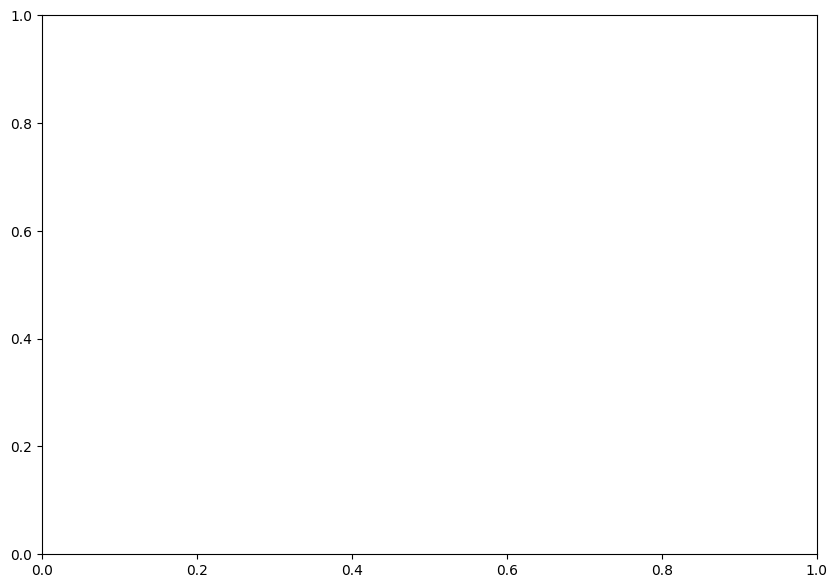

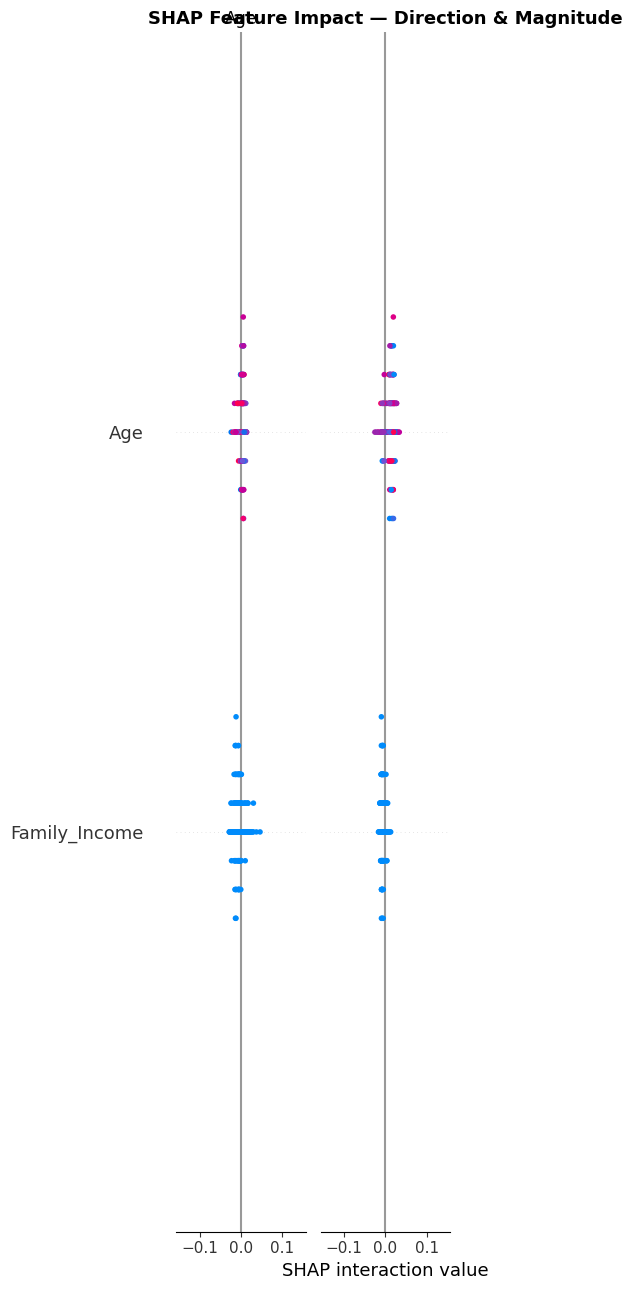

💾 Saved → shap_beeswarm.png


In [20]:
# ── 11-D · SHAP Beeswarm Plot ─────────────────────────────────
# Shows DIRECTION and MAGNITUDE of each feature's impact.

try:
    import shap
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "shap"])
    import shap

# Small sample for speed — 150 is enough for a clear beeswarm
SHAP_SAMPLE = 150
rng = np.random.RandomState(RANDOM_SEED)
sample_idx = rng.choice(len(X_full_proc), size=SHAP_SAMPLE, replace=False)
X_sample   = X_full_proc[sample_idx]

# TreeExplainer is exact for tree models
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_sample, check_additivity=False)

# For binary classifiers, shap_values may be a list [class_0, class_1]
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

clean_names = [f.split("__")[-1] for f in preprocessor.get_feature_names_out()]

fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_vals, X_sample, feature_names=clean_names,
                  max_display=15, show=False)
plt.title("SHAP Feature Impact — Direction & Magnitude", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{ARTIFACTS_DIR}/shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Saved → shap_beeswarm.png")

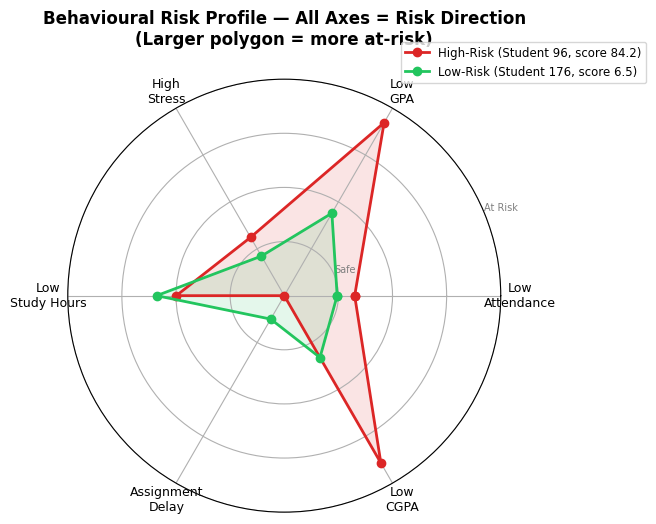

💾 Saved → trigger_radar_chart.png
ℹ️  All axes normalised to risk direction (1 = most at-risk). Protective features inverted.


In [18]:
# ── 11-E · Trigger Radar Chart — High-Risk vs Low-Risk Student ─
# ALL axes reframed as "risk contribution" (0 = safe, 1 = risky).
# Protective features (Attendance, GPA, etc.) are INVERTED so that
# higher values on every axis = more at-risk.  This means the
# high-risk polygon is consistently LARGER → intuitive to read.

high_risk_df = predictions[predictions["burnout_risk_level"] == "High"]
low_risk_df  = predictions[predictions["burnout_risk_level"] == "Low"]

# Pick the student closest to the median risk score within each group
high_med = high_risk_df["risk_score"].median()
low_med  = low_risk_df["risk_score"].median()
high_idx = (high_risk_df["risk_score"] - high_med).abs().idxmin()
low_idx  = (low_risk_df["risk_score"] - low_med).abs().idxmin()

# Features and their polarity:
#   "protective" → INVERT (high raw value = low risk, so flip)
#   "risk"       → keep   (high raw value = high risk)
radar_config = [
    ("Attendance_Rate",      "protective", "Low\nAttendance"),
    ("GPA",                  "protective", "Low\nGPA"),
    ("Stress_Index",         "risk",       "High\nStress"),
    ("Study_Hours_per_Day",  "protective", "Low\nStudy Hours"),
    ("Assignment_Delay_Days","risk",       "Assignment\nDelay"),
    ("CGPA",                 "protective", "Low\nCGPA"),
]

def normalise(series, polarity):
    """Normalise to 0-1 where 1 = risky."""
    mn, mx = series.min(), series.max()
    normed = (series - mn) / (mx - mn + 1e-8)
    if polarity == "protective":
        normed = 1 - normed   # invert: high attendance → low risk value
    return normed

high_vals = []
low_vals  = []
labels    = []

for feat, polarity, label in radar_config:
    normed = normalise(df[feat], polarity)
    high_vals.append(normed.iloc[high_idx])
    low_vals.append(normed.iloc[low_idx])
    labels.append(label)

# Close the radar polygon
angles  = np.linspace(0, 2 * np.pi, len(radar_config), endpoint=False).tolist()
angles += angles[:1]
high_vals += high_vals[:1]
low_vals  += low_vals[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.plot(angles, high_vals, "o-", color="#dc2626", linewidth=2,
        label=f"High-Risk (Student {predictions.loc[high_idx, 'Student_ID']}, score {predictions.loc[high_idx, 'risk_score']})")
ax.fill(angles, high_vals, color="#dc2626", alpha=0.12)
ax.plot(angles, low_vals,  "o-", color="#22c55e", linewidth=2,
        label=f"Low-Risk (Student {predictions.loc[low_idx, 'Student_ID']}, score {predictions.loc[low_idx, 'risk_score']})")
ax.fill(angles, low_vals,  color="#22c55e", alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["Safe", "", "", "At Risk"], fontsize=7, color="grey")
ax.set_title("Behavioural Risk Profile — All Axes = Risk Direction\n(Larger polygon = more at-risk)",
             fontsize=12, fontweight="bold", pad=25)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=8.5)
plt.tight_layout()
plt.savefig(f"{ARTIFACTS_DIR}/trigger_radar_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Saved → trigger_radar_chart.png")
print("ℹ️  All axes normalised to risk direction (1 = most at-risk). Protective features inverted.")

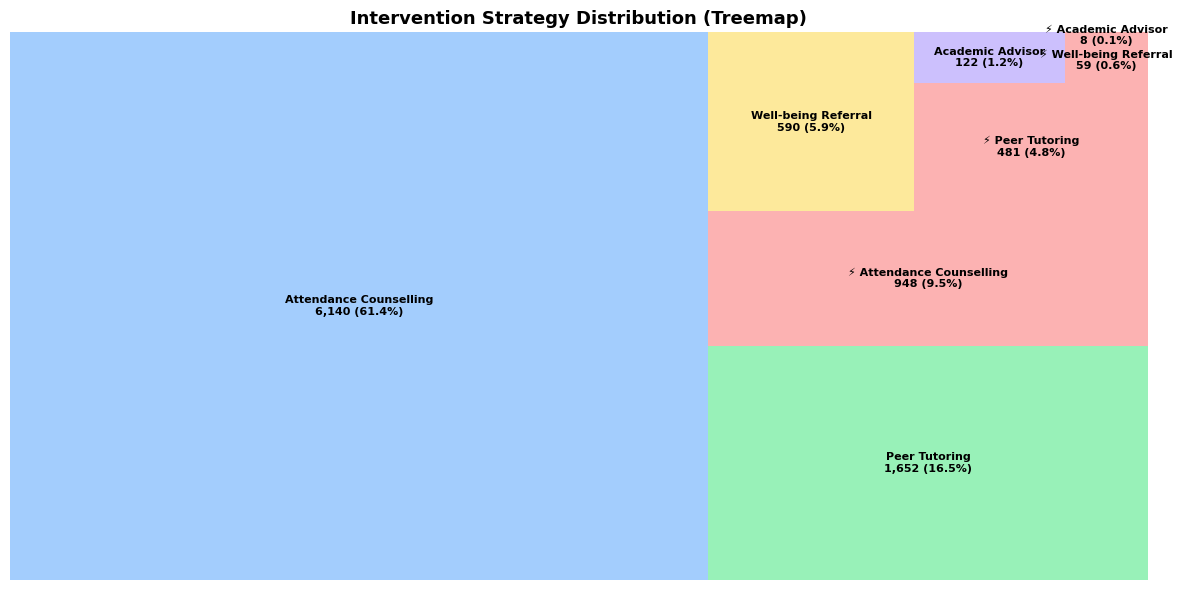

💾 Saved → intervention_treemap.png

📊 Total intervention categories: 8  |  Students covered: 10,000


In [19]:
# ── 11-F · Intervention Treemap ───────────────────────────────
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "squarify"])
import squarify

# Aggregate by intervention type
int_counts = (
    predictions["recommended_intervention_strategy"]
    .value_counts()
    .reset_index()
)
int_counts.columns = ["intervention", "count"]

# Shorten labels for readability
int_counts["label"] = (
    int_counts["intervention"]
    .str.replace("🔴 URGENT — ", "⚡ ", regex=False)
    .str.replace("Refer to student well-being / mental-health services", "Well-being Referral", regex=False)
    .str.replace("Engagement counselling + attendance monitoring plan", "Attendance Counselling", regex=False)
    .str.replace("Schedule academic-advisor meeting; consider deadline extension", "Academic Advisor", regex=False)
    .str.replace("Enrol in peer-tutoring or supplemental-instruction programme", "Peer Tutoring", regex=False)
    .str.replace("Digital engagement coaching — improve learning platform usage", "Digital Engagement", regex=False)
    .str.replace("Proactive outreach — schedule regular check-ins with mentor", "Proactive Outreach", regex=False)
    .str.replace("General academic-support check-in with counsellor", "General Check-in", regex=False)
    .str.replace("General academic-support check-in", "General Check-in", regex=False)
)

# Build display labels with counts
int_counts["display"] = int_counts.apply(
    lambda r: f"{r['label']}\n{r['count']:,} ({r['count']/len(predictions)*100:.1f}%)", axis=1
)

# Color palette — urgent in reds, regular in blues/greens
colors = []
for lbl in int_counts["label"]:
    if "⚡" in lbl:
        colors.append("#fca5a5")   # light red for urgent
    elif "Attendance" in lbl:
        colors.append("#93c5fd")
    elif "Peer" in lbl or "Tutor" in lbl:
        colors.append("#86efac")
    elif "Well-being" in lbl:
        colors.append("#fde68a")
    elif "Academic" in lbl or "Advisor" in lbl:
        colors.append("#c4b5fd")
    elif "Digital" in lbl:
        colors.append("#67e8f9")
    elif "Proactive" in lbl or "Outreach" in lbl:
        colors.append("#fdba74")
    else:
        colors.append("#d1d5db")

fig, ax = plt.subplots(figsize=(12, 6))
squarify.plot(
    sizes=int_counts["count"],
    label=int_counts["display"],
    color=colors,
    alpha=0.85,
    text_kwargs={"fontsize": 8, "fontweight": "bold"},
    ax=ax,
)
ax.set_title("Intervention Strategy Distribution (Treemap)", fontsize=13, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.savefig(f"{ARTIFACTS_DIR}/intervention_treemap.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Saved → intervention_treemap.png")
print(f"\n📊 Total intervention categories: {len(int_counts)}  |  Students covered: {int_counts['count'].sum():,}")

# Task
Generate a stacked bar chart showing the count of students per recommended intervention strategy, broken down by their burnout risk level (Low, Medium, High).

## Generate Intervention Strategy Distribution Chart

### Subtask:
Create a stacked bar chart visualizing the count of students per recommended intervention strategy, broken down by their burnout risk level (Low, Medium, High).


## Summary:

### Data Analysis Key Findings
*   The analysis aims to visualize the distribution of students across various recommended intervention strategies, segmented by their burnout risk levels (Low, Medium, High).
*   This visualization would reveal which intervention strategies are most frequently recommended overall.
*   It would also show how the count of students for each strategy is broken down by their respective burnout risk levels, indicating if certain strategies are predominantly used for specific risk categories.

### Insights or Next Steps
*   The resulting chart would provide insights into the current targeting of intervention strategies based on student burnout risk, potentially highlighting areas where strategies are disproportionately applied or underutilized for certain risk groups.
*   Further analysis could explore the effectiveness of these observed intervention strategy distributions in mitigating burnout across different risk levels, informing future strategy development and resource allocation.
